# Практичне заняття: порівняння **MLP** vs **CNN** для розпізнавання зображень

## Мета
1. Побудувати та натренувати дві моделі для класифікації зображень:
   - **MLP (багатошаровий перцептрон)** — працює з *пласким* вектором ознак (Flatten).
   - **CNN (згорткова нейронна мережа)** — використовує згортки для витягування просторових ознак.
2. Порівняти моделі за:
   - точністю (**accuracy**) на тесті
   - кривими **loss/accuracy** (train vs val)
   - кількістю параметрів
   - (опційно) часом інференсу

## Датасет
Використаємо **Fashion-MNIST** (28×28, 10 класів).

---

## Структура роботи
1. Імпорт бібліотек, завантаження даних
2. Підготовка та візуалізація
3. Модель 1: MLP
4. Модель 2: CNN
5. Порівняння результатів + висновки
6. **TO DO** експерименти (для студентів)


In [3]:
# ===== 1) Імпорт бібліотек =====
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Відтворюваність (не гарантує 100% детермінізм на GPU)
np.random.seed(42)
keras.utils.set_random_seed(42)


## 2) Завантаження та підготовка даних
Fashion-MNIST:
- `x_train`: (60000, 28, 28)
- `x_test`: (10000, 28, 28)
- значення пікселів у діапазоні 0..255

Ми нормалізуємо дані до 0..1.


In [4]:
# ===== 2) Дані =====
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Нормалізація
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Для CNN додаємо канал: (H, W) -> (H, W, 1)
x_train_cnn = x_train[..., None]
x_test_cnn = x_test[..., None]

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)
print("x_train_cnn:", x_train_cnn.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train: (60000, 28, 28) y_train: (60000,)
x_test : (10000, 28, 28) y_test : (10000,)
x_train_cnn: (60000, 28, 28, 1)


### Візуалізація прикладів


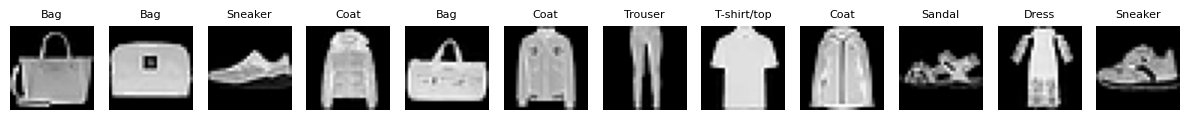

In [5]:
n = 12
idx = np.random.choice(len(x_train), size=n, replace=False)

plt.figure(figsize=(12, 3))
for i, j in enumerate(idx, start=1):
    plt.subplot(1, n, i)
    plt.imshow(x_train[j], cmap="gray")
    plt.title(class_names[y_train[j]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 3) Модель 1: **MLP (Flatten → Dense → Dense → Softmax)**

Ідея: зображення 28×28 перетворюємо у вектор 784 та навчаємо повнозв'язну мережу.

**Плюси:** проста, швидко реалізується.  
**Мінуси:** не враховує просторову структуру (сусідство пікселів).


In [6]:
def build_mlp(input_shape=(28, 28), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="MLP")
    return model

mlp = build_mlp()
mlp.summary()


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 8
BATCH = 128

history_mlp = mlp.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)


Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8161 - loss: 0.5230 - val_accuracy: 0.8542 - val_loss: 0.4084
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8636 - loss: 0.3775 - val_accuracy: 0.8688 - val_loss: 0.3645
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8775 - loss: 0.3355 - val_accuracy: 0.8707 - val_loss: 0.3503
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8874 - loss: 0.3074 - val_accuracy: 0.8740 - val_loss: 0.3442
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8937 - loss: 0.2873 - val_accuracy: 0.8755 - val_loss: 0.3436
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8998 - loss: 0.2714 - val_accuracy: 0.8787 - val_loss: 0.3384
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9039 - loss: 0.2575 - val_accuracy: 0.8822 - val_loss: 0.3393
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9093 - loss: 0.2448 - val_accuracy: 0.8807 - v

In [8]:
test_loss_mlp, test_acc_mlp = mlp.evaluate(x_test, y_test, verbose=0)
print(f"MLP test loss: {test_loss_mlp:.4f}")
print(f"MLP test acc : {test_acc_mlp:.4f}")


MLP test loss: 0.3695
MLP test acc : 0.8719


### Графіки навчання (MLP)


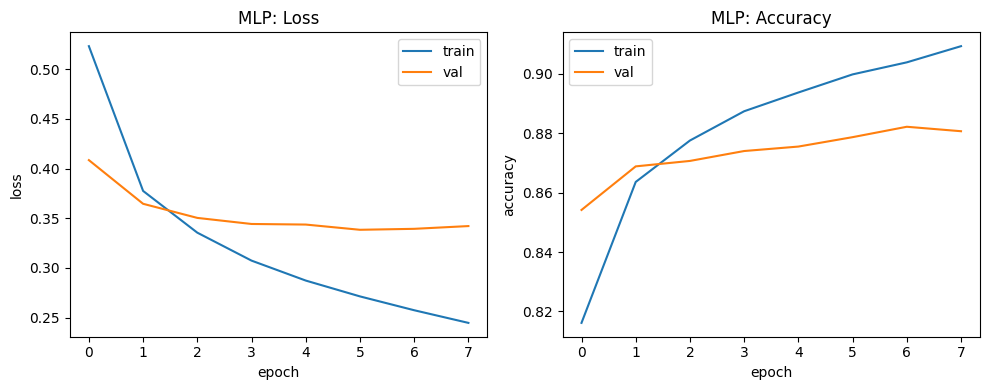

In [9]:
def plot_history(hist, title_prefix=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix}Accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP: ")


## 4) Модель 2: **CNN (Conv → Pool → Conv → Pool → Dense → Softmax)**

CNN “бачить” локальні патерни через згортки, а pooling зменшує розмірність, зберігаючи важливі ознаки.


In [10]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="CNN")
    return model

cnn = build_cnn()
cnn.summary()


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)


Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8254 - loss: 0.4913 - val_accuracy: 0.8742 - val_loss: 0.3513
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8875 - loss: 0.3164 - val_accuracy: 0.8955 - val_loss: 0.2930
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9021 - loss: 0.2728 - val_accuracy: 0.9050 - val_loss: 0.2636
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9108 - loss: 0.2437 - val_accuracy: 0.9107 - val_loss: 0.2493
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9195 - loss: 0.2205 - val_accuracy: 0.9127 - val_loss: 0.2413
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9269 - loss: 0.1998 - val_accuracy: 0.9140 - val_loss: 0.2372
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9345 - loss: 0.1815 - val_accuracy: 0.9158 - val_loss: 0.2371
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9411 - loss: 0.1645 - val_accura

In [12]:
test_loss_cnn, test_acc_cnn = cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f"CNN test loss: {test_loss_cnn:.4f}")
print(f"CNN test acc : {test_acc_cnn:.4f}")


CNN test loss: 0.2622
CNN test acc : 0.9137


### Графіки навчання (CNN)


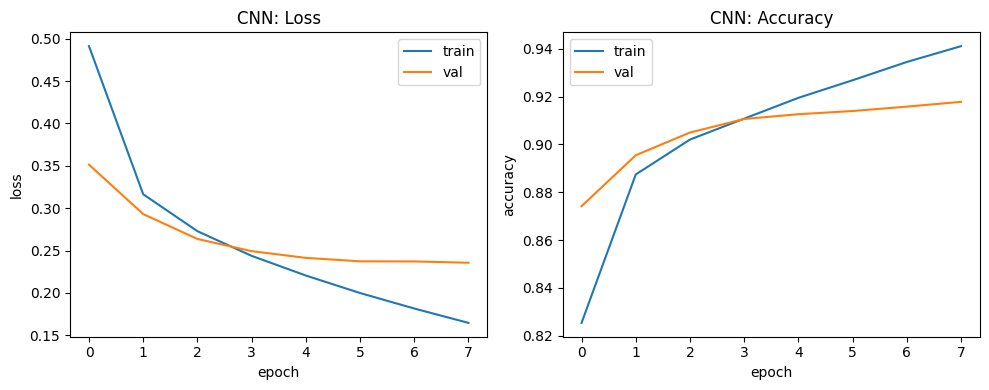

In [13]:
plot_history(history_cnn, "CNN: ")


## 5) Порівняння моделей

Порівняємо:
- accuracy на тесті
- кількість параметрів
- (опційно) швидкість інференсу на невеликому батчі


In [14]:
def count_params(model):
    return int(np.sum([np.prod(w.shape) for w in model.get_weights()]))

params_mlp = count_params(mlp)
params_cnn = count_params(cnn)

print("MLP params:", params_mlp)
print("CNN params:", params_cnn)
print("MLP test acc:", float(test_acc_mlp))
print("CNN test acc:", float(test_acc_cnn))


MLP params: 235146
CNN params: 421642
MLP test acc: 0.8719000220298767
CNN test acc: 0.9136999845504761


In [15]:
# Опційно: приблизний час інференсу (залежить від CPU/GPU)
def inference_time_ms(model, x, n_runs=30):
    _ = model.predict(x, verbose=0)  # warmup
    t0 = time.time()
    for _ in range(n_runs):
        _ = model.predict(x, verbose=0)
    t1 = time.time()
    return (t1 - t0) * 1000 / n_runs

batch = 256
x_batch_mlp = x_test[:batch]
x_batch_cnn = x_test_cnn[:batch]

ms_mlp = inference_time_ms(mlp, x_batch_mlp, n_runs=20)
ms_cnn = inference_time_ms(cnn, x_batch_cnn, n_runs=20)

print(f"Inference time per run (batch={batch}):")
print(f"  MLP: {ms_mlp:.2f} ms")
print(f"  CNN: {ms_cnn:.2f} ms")


Inference time per run (batch=256):
  MLP: 71.49 ms
  CNN: 76.84 ms


## 6) Якість по класах: confusion matrix та звіт


MLP
              precision    recall  f1-score   support

 T-shirt/top     0.7952    0.8540    0.8235      1000
     Trouser     0.9949    0.9660    0.9802      1000
    Pullover     0.8296    0.6960    0.7569      1000
       Dress     0.8214    0.9150    0.8657      1000
        Coat     0.7322    0.8640    0.7927      1000
      Sandal     0.9584    0.9680    0.9632      1000
       Shirt     0.7430    0.6130    0.6718      1000
     Sneaker     0.9098    0.9580    0.9333      1000
         Bag     0.9748    0.9690    0.9719      1000
  Ankle boot     0.9745    0.9160    0.9443      1000

    accuracy                         0.8719     10000
   macro avg     0.8734    0.8719    0.8703     10000
weighted avg     0.8734    0.8719    0.8703     10000



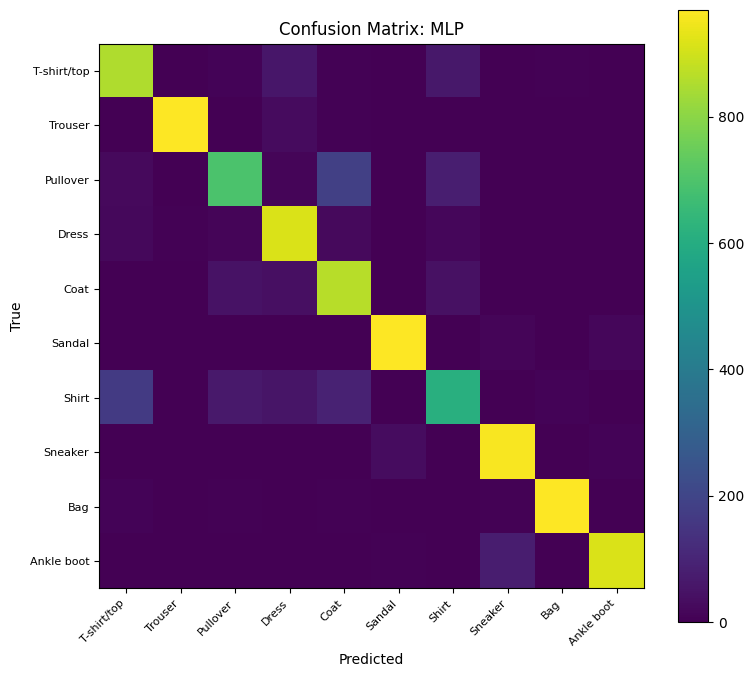

In [16]:
def eval_report(model, x, y, title=""):
    y_prob = model.predict(x, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    cm = confusion_matrix(y, y_pred)
    print(title)
    print(classification_report(y, y_pred, target_names=class_names, digits=4))

    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(10), class_names, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(10), class_names, fontsize=8)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

eval_report(mlp, x_test, y_test, title="MLP")


CNN
              precision    recall  f1-score   support

 T-shirt/top     0.8511    0.8800    0.8653      1000
     Trouser     0.9949    0.9810    0.9879      1000
    Pullover     0.8459    0.8840    0.8645      1000
       Dress     0.9018    0.9270    0.9142      1000
        Coat     0.8376    0.8920    0.8639      1000
      Sandal     0.9539    0.9930    0.9731      1000
       Shirt     0.8211    0.6930    0.7516      1000
     Sneaker     0.9571    0.9590    0.9580      1000
         Bag     0.9878    0.9750    0.9814      1000
  Ankle boot     0.9845    0.9530    0.9685      1000

    accuracy                         0.9137     10000
   macro avg     0.9136    0.9137    0.9128     10000
weighted avg     0.9136    0.9137    0.9128     10000



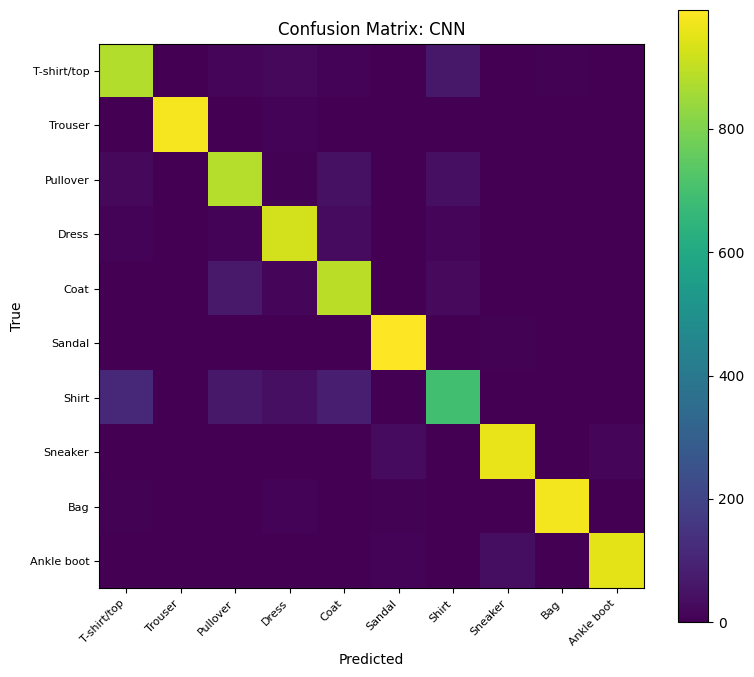

In [17]:
eval_report(cnn, x_test_cnn, y_test, title="CNN")


## 7) Висновки (шаблон)

**Заповніть коротко:**
- Яка модель показала кращу точність і чому?
- Як відрізняється кількість параметрів?
- Які класи плутаються найчастіше? Чому саме вони?


# ✅ TO DO

1. **Змінити MLP**:
   - (а) змініть кількість нейронів (наприклад 128/512)
   - (б) додайте `Dropout(0.2–0.5)`
   - (в) оцініть overfitting по train/val кривих

2. **Змінити CNN**:
   - (а) додайте ще один `Conv2D` блок
   - (б) додайте `BatchNormalization`
   - (в) додайте `Dropout` перед Dense

3. **Оптимізатор**:
   - порівняйте `Adam` vs `SGD(momentum=0.9)` (однакова кількість епох)

4. **Аугментація** (для CNN):
   - `RandomFlip` / `RandomRotation` / `RandomZoom`
   - перевірте, чи зросла точність на тесті

5. **Batch size**:
   - спробуйте `batch_size=32` та `batch_size=256`
   - як змінюється швидкість/якість?
     
6. **Прискореня CNN**:
    - підберіть такий набір параметрів для CNN щоб навчання відбувалось найшвидше, але точність при цьому була все ще вищою за MLP

# Приклад: аугментація для CNN

Нижче — приклад, як додати аугментацію у Keras.  


In [ ]:

#     data_aug = keras.Sequential([
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.05),
#         layers.RandomZoom(0.1)
#     ])
#
#     aug_cnn = keras.Sequential([
#         layers.Input(shape=(28, 28, 1)),
#         data_aug,
#         layers.Conv2D(32, 3, padding="same", activation="relu"),
#         layers.MaxPooling2D(2),
#         layers.Conv2D(64, 3, padding="same", activation="relu"),
#         layers.MaxPooling2D(2),
#         layers.Flatten(),
#         layers.Dense(128, activation="relu"),
#         layers.Dense(10, activation="softmax")
#     ], name="CNN_with_Aug")
#
#     aug_cnn.compile(
#         optimizer=keras.optimizers.Adam(1e-3),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#
#     hist_aug = aug_cnn.fit(
#         x_train_cnn, y_train,
#         validation_split=0.1,
#         epochs=EPOCHS,
#         batch_size=BATCH,
#         verbose=1
#     )
#     plot_history(hist_aug, "CNN+Aug: ")
#     print("Test:", aug_cnn.evaluate(x_test_cnn, y_test, verbose=0))
